<a href="https://colab.research.google.com/github/harishmk31/24ADI003_24BAD031/blob/main/exp_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Harish M K - 24BAD031
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


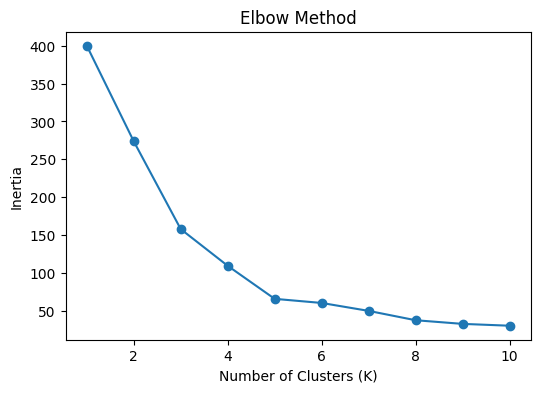


Clustered Data:
    Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0       0   19                  15                      39        4
1       0   21                  15                      81        2
2       1   20                  16                       6        4
3       1   23                  16                      77        2
4       1   31                  17                      40        4


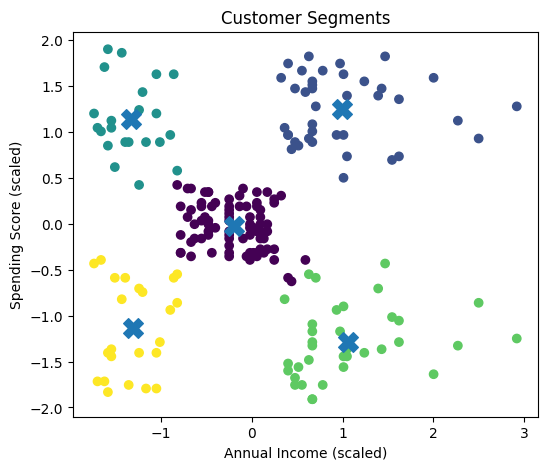


Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091

Cluster Means:

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [2]:
print("Harish M K - 24BAD031")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv("Mall_Customers.csv")

print(df.head())

print("\nMissing Values:\n", df.isnull().sum())

df = df.drop("CustomerID", axis=1)

df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []

K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = labels

print("\nClustered Data:\n", df.head())

plt.figure(figsize=(6,5))

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')

centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, marker='X')

plt.title("Customer Segments")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

print("\nInertia:", kmeans.inertia_)
sil_score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", sil_score)

print("\nCluster Means:\n")
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

Harish M K - 24BAD031
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


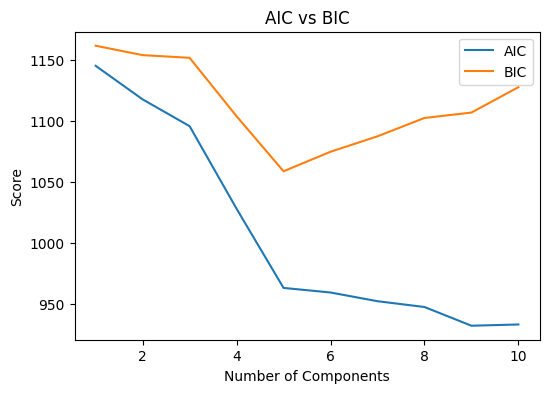


Clustered Data:
    Gender  Age  Annual Income (k$)  Spending Score (1-100)  GMM_Cluster
0       0   19                  15                      39            4
1       0   21                  15                      81            2
2       1   20                  16                       6            4
3       1   23                  16                      77            2
4       1   31                  17                      40            4

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


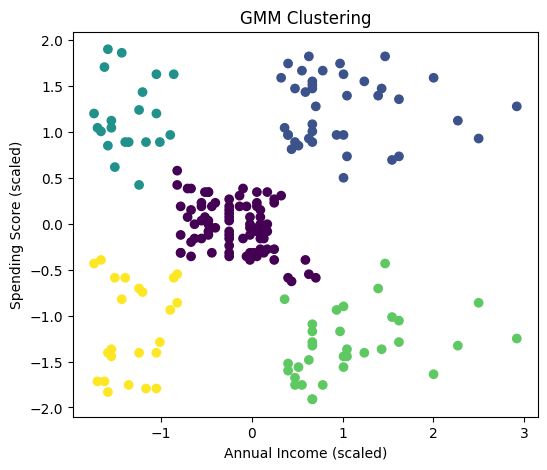


Cluster Probabilities (first 5 rows):

[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


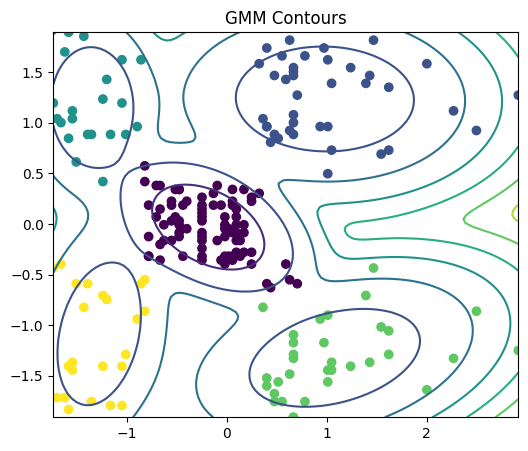

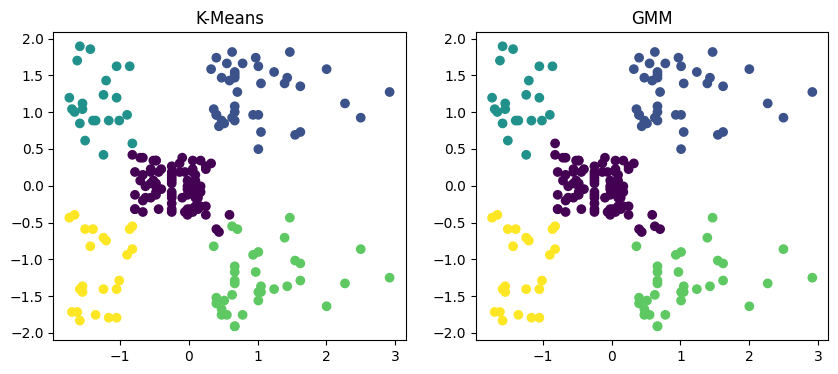


GMM Cluster Means:

             Annual Income (k$)  Spending Score (1-100)
GMM_Cluster                                            
0                     55.642857               49.369048
1                     86.538462               82.128205
2                     25.095238               80.047619
3                     88.818182               16.000000
4                     26.304348               20.913043


In [3]:
print("Harish M K - 24BAD031")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

df = pd.read_csv("Mall_Customers.csv")

print(df.head())

print("\nMissing Values:\n", df.isnull().sum())

df = df.drop("CustomerID", axis=1)

df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

aic = []
bic = []
K_range = range(1, 11)

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

plt.figure(figsize=(6,4))
plt.plot(K_range, aic, label='AIC')
plt.plot(K_range, bic, label='BIC')
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("AIC vs BIC")
plt.legend()
plt.show()

k = 5
gmm = GaussianMixture(n_components=k, random_state=42)
gmm.fit(X_scaled)

probs = gmm.predict_proba(X_scaled)

labels = gmm.predict(X_scaled)
df['GMM_Cluster'] = labels

print("\nClustered Data:\n", df.head())

print("\nLog-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))

sil_score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", sil_score)

plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.title("GMM Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

print("\nCluster Probabilities (first 5 rows):\n")
print(probs[:5])

import numpy as np

x = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)
y = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)
grid = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

Z = -gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)

plt.figure(figsize=(6,5))
plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.title("GMM Contours")
plt.show()

kmeans = KMeans(n_clusters=k, random_state=42)
k_labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=k_labels, cmap='viridis')
plt.title("K-Means")

plt.subplot(1,2,2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.title("GMM")

plt.show()

print("\nGMM Cluster Means:\n")
print(df.groupby('GMM_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())